# Sailfort data analysis

#### Introduction : 
Salifort Motors is a fictional French-based alternative energy vehicle manufacturer. Its global workforce of over 100,000 employees research, design, construct, validate, and distribute electric, solar, algae, and hydrogen-based vehicles. Salifort’s end-to-end vertical integration model has made it a global leader at the intersection of alternative energy and automobiles.

#### Goal : 
Constructing a classification model that will predict the employe's churn rate




In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, mean_squared_error, r2_score
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder




In [16]:
df= pd.read_csv("HR_capstone_dataset.csv")
df.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


# EDA : Exploratory Data Analysis
At this stage we will explore the data and handle any necessary cleaning, visualization & data manipulation. This step concerns the following - 
* Missing data handling
* checking relation between different features
* visualizing the same
* checking for negative values and outlier 
* aggregated analysis
* data type correction
* feature engineering

### Dataset Attributes 

| Variable | Description |
|---|---|
| satisfaction_level | Employee-reported job satisfaction level [0–1] |
| last_evaluation | Score of employee's last performance review [0–1] |
| number_project | Number of projects employee contributes to |
| average_monthly_hours | Average number of hours employee worked per month |
| time_spend_company | How long the employee has been with the company (years) |
| Work_accident | Whether or not the employee experienced an accident while at work |
| left | Whether or not the employee left the company |
| promotion_last_5years | Whether or not the employee was promoted in the last 5 years |
| Department | The employee's department |
| salary | The employee's salary (U.S. dollars) |



In [17]:
df.shape
df.info()

#there are no missing values in the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [18]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


Statistical data of numerical features shows the following -

* there are no features containing negative values.
* data in the features consisting boolean values , might be skewed..
* there are no unrealistic maximum values.


In [19]:
# checking for duplicates
df.loc[df.duplicated()].shape

(3008, 10)

In [20]:
#removing duplicates
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [21]:
# converting catehorical data to numerical data before proceeidng
#encoding the 'Salary' & Department column
salary_mapping = {'low': 1, 'medium': 2, 'high': 3}
df['salary_mapped'] = df['salary'].map(salary_mapping)
department_mapping = {'sales': 1, 'technical': 2, 'support': 3, 'management': 4, 'IT': 5, 'product_mng': 6, 'marketing': 7, 'RandD': 8, 'accounting': 9, 'hr': 10, 'finance': 11}
df['Department_mapped'] = df['Department'].map(department_mapping)

In [22]:
#drop the original categorical columns'
df.drop(df[['salary', 'Department']], axis=1, inplace=True)

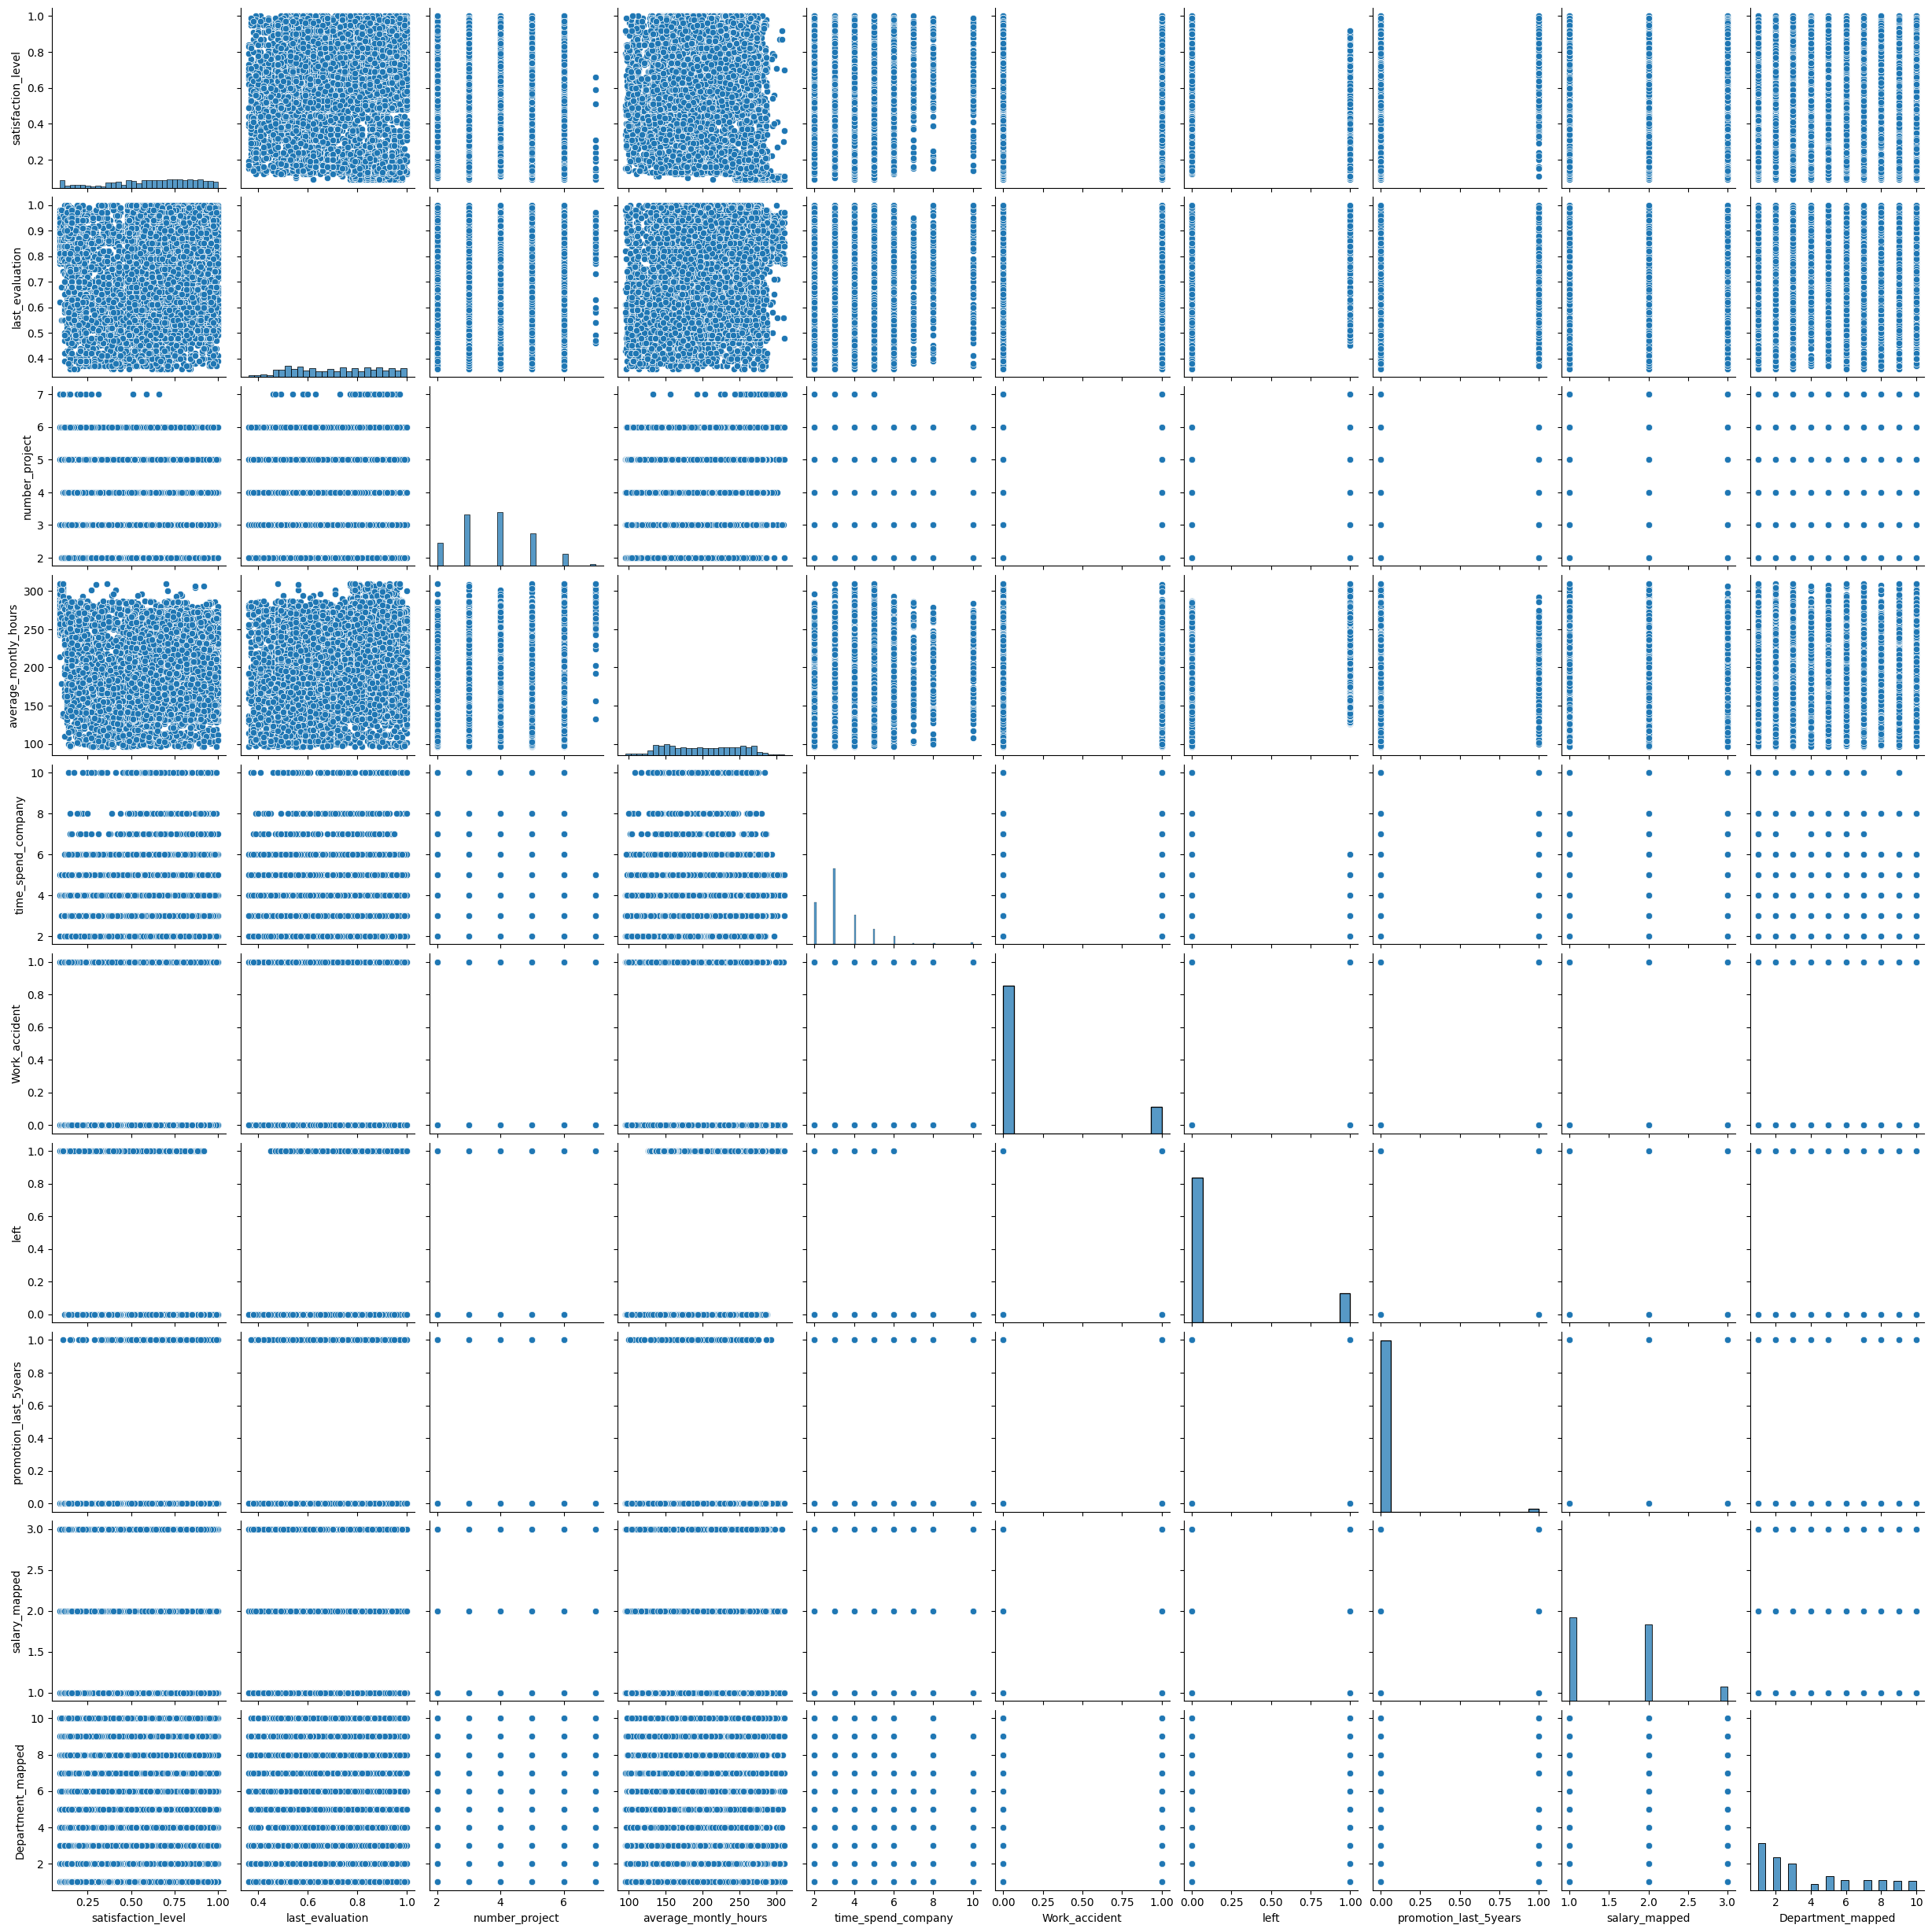

In [23]:
#Now lets visualize the the data in a pairplot.

sns.pairplot(df)
plt.show()

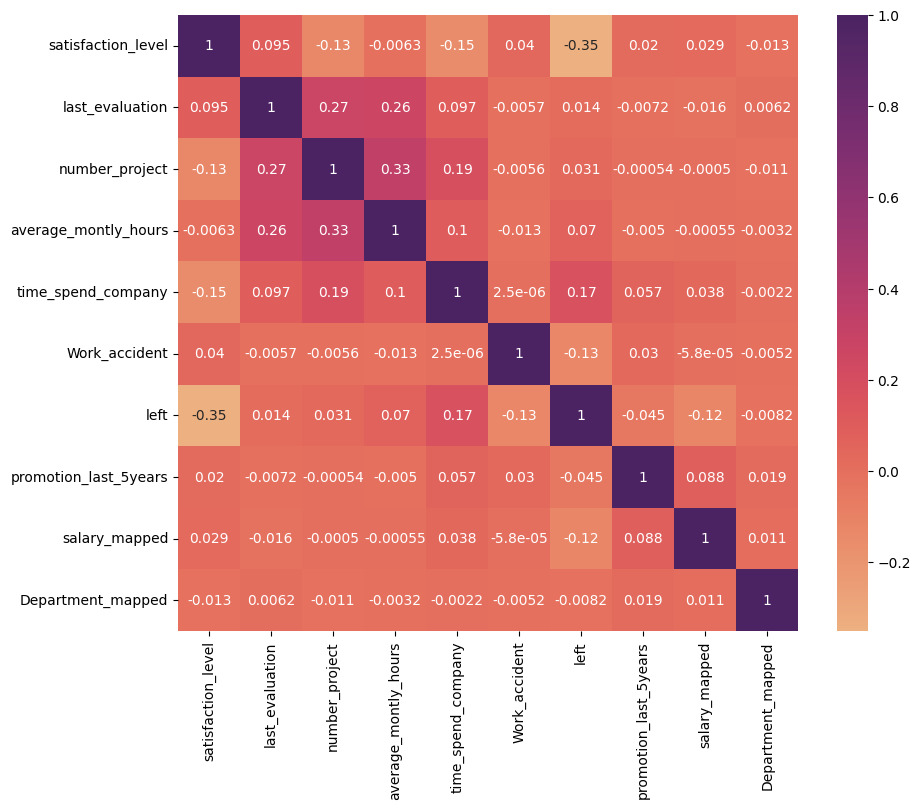

In [24]:
#viewing correlation between features
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(method='pearson'), annot=True, cmap='flare')
plt.show()

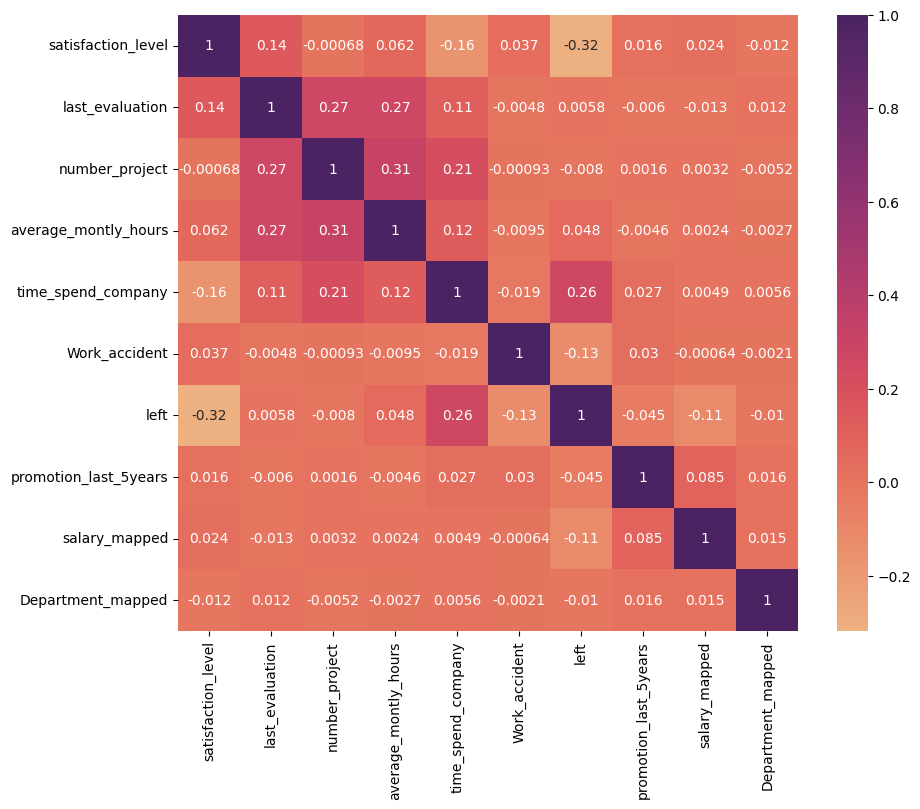

In [25]:
#viewing correlation between features- using spearman method
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(method='spearman'), annot=True, cmap='flare')
plt.show()

### From the visualization aboebe we can observe the followings.
#### Imbalanced data
* The target variable - 'left' - Did the employee left the organisation ?  is highly skewed.
* several features - 'Work_accident', 'Promotion_last_5years', & 'Salary_mapped' is also skewed.
 
#### Correlation among features.
* The highest level of correlation observed in the dataset is 33% and between 'number_project' and 'average_monthly_hours'.

#### Next Steps -

* **Imbalanced data** - Since we will be constructing treebased models i.e Randomforest, scaling is not required.Because Randomforest is a tree based ensemble model it does not assume linear or any other simple relation between features and target variable. Moreover , its a non-parametric model and make predictions by splitting data at each leaf based on different conditions.

* **Correlation** - 33% correlation among two features can be negligible


In [26]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary_mapped,Department_mapped
0,0.38,0.53,2,157,3,0,1,0,1,1
1,0.80,0.86,5,262,6,0,1,0,2,1
2,0.11,0.88,7,272,4,0,1,0,2,1
3,0.72,0.87,5,223,5,0,1,0,1,1
4,0.37,0.52,2,159,3,0,1,0,1,1


In [27]:
#feature engineering
df['avg_project_per_year']= (df['number_project']/df['time_spend_company']).round(2)
df.head()  

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary_mapped,Department_mapped,avg_project_per_year
0,0.38,0.53,2,157,3,0,1,0,1,1,0.67
1,0.80,0.86,5,262,6,0,1,0,2,1,0.83
2,0.11,0.88,7,272,4,0,1,0,2,1,1.75
3,0.72,0.87,5,223,5,0,1,0,1,1,1.00
4,0.37,0.52,2,159,3,0,1,0,1,1,0.67


In [28]:
X= df.drop('left', axis=1)
y= df['left']

x_train, x_test, y_train, y_test= train_test_split(X, y, test_size=0.3,stratify=y, random_state=23)

We Will Construct two models - Randomforest and Xgboost and compare their performance. We will also perform hyperparameter tuning to optimize the models.


### XGB Model

In [31]:
xg= xgb.XGBClassifier(random_state=23)
score= ['accuracy', 'recall', 'f1', 'precision']
params= { 
    'max_depth' : [3,4,5],
    'n_estimators' : [100, 200, 300, 400],
    'min_child_weight' : [1, 2, 3],
    'learning_rate' : [0.01, 0.02, 0.03, 0.04, 0.05],
    'subsample' : [0.8,  0.9, 1],
    'reg_lambda' : [1],
}

In [32]:
%%time
grid_cv= GridSearchCV(estimator=xg, param_grid=params, scoring=score, refit='f1', cv=5, n_jobs=-1) #n_jobs=-1 will use all the cores of the processor to perform the grid search
grid_cv.fit(x_train, y_train)

CPU times: total: 26.2 s
Wall time: 1min 56s


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.02, 0.03, 0.04, 0.05],
                         'max_depth': [3, 4, 5], 'min_child_weight': [1, 2, 3],
                         'n_estimators': [100, 200, 300, 400],
                         'reg_lambda': [1], 'subsample': [0.8, 0.9, 1]},
             refit='f1', scoring=['accuracy', 'recall', 'f1', 'precision'])

In [36]:
grid_y_pred= grid_cv.predict(x_test)
precision_sc= precision_score(y_test, grid_y_pred)
recall_sc = recall_score(y_test, grid_y_pred)
f1_sc= f1_score(y_test, grid_y_pred)

print(f"Precision_score : {precision_sc}, recall_score : {recall_sc}, f1_sc : {f1_sc}" )

Precision_score : 0.9803220035778175, recall_score : 0.9179229480737019, f1_sc : 0.9480968858131488


In [38]:
grid_cv.best_params_

{'learning_rate': 0.03,
 'max_depth': 5,
 'min_child_weight': 1,
 'n_estimators': 400,
 'reg_lambda': 1,
 'subsample': 1}

In [40]:
#Final Model
xg_final= xgb.XGBClassifier(learning_rate=0.03,
 max_depth=5,
 min_child_weight=1,
 n_estimators=400,
 reg_lambda=1,
 subsample=1)

xg_final.fit(x_train, y_train)

y_pred= xg_final.predict(x_test)
precision1 = precision_score(y_test, y_pred)
recall1 = recall_score(y_test, y_pred)
f1_1 = f1_score(y_test, y_pred)

print(f"Precision_score : {precision1}, recall_score : {recall1}, f1_sc : {f1_1}" )

Precision_score : 0.9803220035778175, recall_score : 0.9179229480737019, f1_sc : 0.9480968858131488


In [46]:
predicted_set= pd.concat([x_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)
predicted_set['Predicted_value']= y_pred

predicted_set.head(50)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary_mapped,Department_mapped,avg_project_per_year,left,Predicted_value
0,0.54,0.96,3,201,3,0,0,2,4,1.00,0,0
1,0.55,0.64,3,138,3,1,0,1,1,1.00,0,0
2,0.40,0.51,2,148,3,0,0,1,1,0.67,1,1
3,0.85,0.74,5,170,4,0,0,1,5,1.25,0,0
4,0.92,0.53,2,249,2,0,0,3,5,1.00,0,0
5,0.36,0.93,3,162,5,0,0,1,3,0.60,0,0
6,0.63,0.76,4,245,3,0,0,1,10,1.33,0,0
7,0.77,0.89,4,153,7,0,0,2,1,0.57,0,0
8,0.84,0.53,3,237,3,1,0,1,1,1.00,0,0
9,0.53,0.61,4,182,3,0,0,1,2,1.33,0,0


### Conclusion : 
In here we can now see a satisfactory result with the scores of the model as follows- 

* Precision_score : 98% 
* recall_score : 0.92% 
* f1_sc : 0.95%

while this might indicate a potential overfitting, based on the tuning we can rely on this model for predicting the target based on similar feature. 

